In [78]:
import json
import numpy as np
import pandas as pd
from datasets import Dataset
from evaluate import load
import matplotlib.pyplot as plt
from transformers import (
    BertTokenizerFast,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    pipeline
)


In [2]:
with open("../data/labeled_data.json", "r", encoding="utf-8") as f:
    data = json.load(f)
data[0]


{'text': 'vou pagar semana que vem pode ser?',
 'id': 2002,
 'entities': [{'start': 4, 'end': 9, 'text': 'pagar', 'labels': ['PAGAMENTO']},
  {'start': 10, 'end': 24, 'text': 'semana que vem', 'labels': ['TEMPO']}],
 'orientacao': [{'start': 4,
   'end': 9,
   'text': 'pagar',
   'labels': ['positiva']},
  {'start': 10, 'end': 24, 'text': 'semana que vem', 'labels': ['positiva']}],
 'modalidade': [{'start': 4,
   'end': 9,
   'text': 'pagar',
   'labels': ['condicional']},
  {'start': 10,
   'end': 24,
   'text': 'semana que vem',
   'labels': ['condicional']}],
 'referencia_temporal': [{'start': 4,
   'end': 9,
   'text': 'pagar',
   'labels': ['futuro']},
  {'start': 10, 'end': 24, 'text': 'semana que vem', 'labels': ['futuro']}],
 'explicitude': [{'start': 4,
   'end': 9,
   'text': 'pagar',
   'labels': ['explicito']},
  {'start': 10, 'end': 24, 'text': 'semana que vem', 'labels': ['explicito']}],
 'annotator': 1,
 'annotation_id': 187,
 'created_at': '2025-05-26T13:11:20.393793Z',

In [3]:
data[0]


{'text': 'vou pagar semana que vem pode ser?',
 'id': 2002,
 'entities': [{'start': 4, 'end': 9, 'text': 'pagar', 'labels': ['PAGAMENTO']},
  {'start': 10, 'end': 24, 'text': 'semana que vem', 'labels': ['TEMPO']}],
 'orientacao': [{'start': 4,
   'end': 9,
   'text': 'pagar',
   'labels': ['positiva']},
  {'start': 10, 'end': 24, 'text': 'semana que vem', 'labels': ['positiva']}],
 'modalidade': [{'start': 4,
   'end': 9,
   'text': 'pagar',
   'labels': ['condicional']},
  {'start': 10,
   'end': 24,
   'text': 'semana que vem',
   'labels': ['condicional']}],
 'referencia_temporal': [{'start': 4,
   'end': 9,
   'text': 'pagar',
   'labels': ['futuro']},
  {'start': 10, 'end': 24, 'text': 'semana que vem', 'labels': ['futuro']}],
 'explicitude': [{'start': 4,
   'end': 9,
   'text': 'pagar',
   'labels': ['explicito']},
  {'start': 10, 'end': 24, 'text': 'semana que vem', 'labels': ['explicito']}],
 'annotator': 1,
 'annotation_id': 187,
 'created_at': '2025-05-26T13:11:20.393793Z',

In [4]:
records = []
for item in data:
    try:
        for i, ent in enumerate(item["entities"]):
            records.append({
                "text":                        item["text"],
                "start":                       ent["start"],
                "end":                         ent["end"],
                "entity_label":                ent["labels"][0],
                "explicitude_label":           item["explicitude"][i]["labels"][0],
                "referencia_temporal_label":   item["referencia_temporal"][i]["labels"][0],
                "modalidade_label":            item["modalidade"][i]["labels"][0],
                "orientacao_label":            item["orientacao"][i]["labels"][0],
            })
    except:
        print(item)
len(records)


725

In [5]:
records[:2]


[{'text': 'vou pagar semana que vem pode ser?',
  'start': 4,
  'end': 9,
  'entity_label': 'PAGAMENTO',
  'explicitude_label': 'explicito',
  'referencia_temporal_label': 'futuro',
  'modalidade_label': 'condicional',
  'orientacao_label': 'positiva'},
 {'text': 'vou pagar semana que vem pode ser?',
  'start': 10,
  'end': 24,
  'entity_label': 'TEMPO',
  'explicitude_label': 'explicito',
  'referencia_temporal_label': 'futuro',
  'modalidade_label': 'condicional',
  'orientacao_label': 'positiva'}]

In [36]:
df = pd.DataFrame(records)
df.head()


,text,start,end,entity_label,explicitude_label,referencia_temporal_label,modalidade_label,orientacao_label
0,vou pagar semana que vem pode ser?,4,9,PAGAMENTO,explicito,futuro,condicional,positiva
1,vou pagar semana que vem pode ser?,10,24,TEMPO,explicito,futuro,condicional,positiva
2,infelizmente não vou conseguir pagar sexta,31,36,PAGAMENTO,explicito,futuro,negado,negativa
3,infelizmente não vou conseguir pagar sexta,37,42,TEMPO,explicito,futuro,negado,negativa
4,preciso de prazo até quando receber meu salário,11,16,CONDIÇÃO,explicito,futuro,condicional,positiva


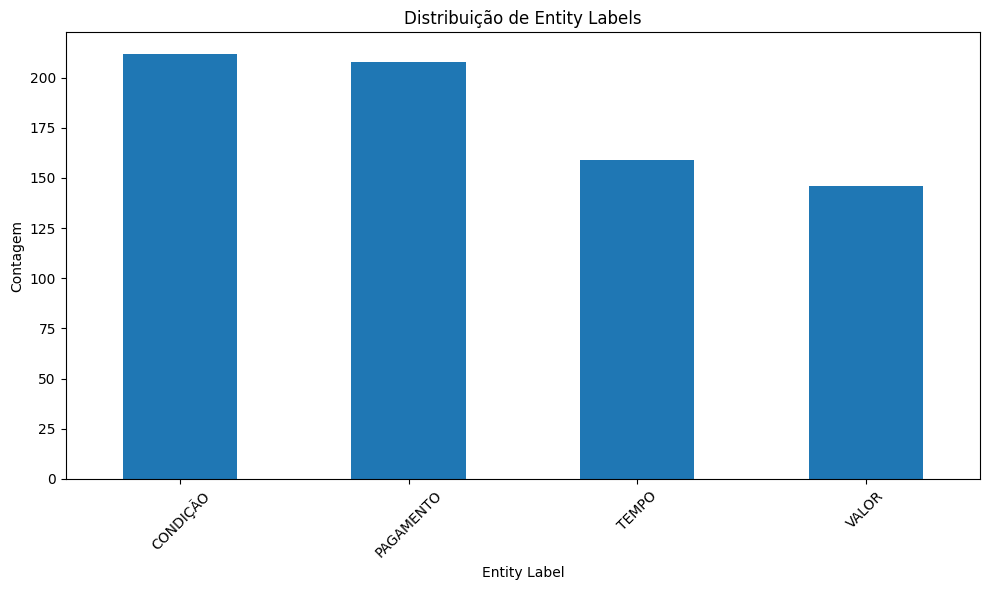

In [37]:
plt.figure(figsize=(10,6))
df['entity_label'].value_counts().plot(kind='bar')
plt.title('Distribuição de Entity Labels')
plt.xlabel('Entity Label')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [38]:
df_entity = df[['text', 'start', 'end', 'entity_label']]
df_entity.head()


,text,start,end,entity_label
0,vou pagar semana que vem pode ser?,4,9,PAGAMENTO
1,vou pagar semana que vem pode ser?,10,24,TEMPO
2,infelizmente não vou conseguir pagar sexta,31,36,PAGAMENTO
3,infelizmente não vou conseguir pagar sexta,37,42,TEMPO
4,preciso de prazo até quando receber meu salário,11,16,CONDIÇÃO


In [39]:
def to_iob_tags(group):
    text = group.name
    labels = ["O"] * len(text)
    for _, row in group.iterrows():
        for i in range(row.start, row.end):
            prefix = "B-" if i == row.start else "I-"
            labels[i] = prefix + row.entity_label
    return pd.DataFrame({"text": text, "tags": [labels]})


In [40]:
iob_df = (
    df_entity
    .groupby("text", sort=False)
    .apply(to_iob_tags)
    .reset_index(drop=True)
)
iob_df.head()


C:\Users\mathe\AppData\Local\Temp\ipykernel_20344\1260785468.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(to_iob_tags)


,text,tags
0,vou pagar semana que vem pode ser?,"[O, O, O, O, B-PAGAMENTO, I-PAGAMENTO, I-PAGAM..."
1,infelizmente não vou conseguir pagar sexta,"[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
2,preciso de prazo até quando receber meu salário,"[O, O, O, O, O, O, O, O, O, O, O, B-CONDIÇÃO, ..."
3,até fim do dia eu pago certinho,"[O, O, O, O, B-TEMPO, I-TEMPO, I-TEMPO, I-TEMP..."
4,ainda hoje sem falta,"[O, O, O, O, O, O, B-TEMPO, I-TEMPO, I-TEMPO, ..."


In [41]:
iob_df["words"] = iob_df["text"].str.split()

def chars_to_word_tags(text, char_tags):
    words = text.split()
    tags = []
    idx = 0
    for w in words:
        chunk = char_tags[idx : idx + len(w)]
        tag = next((t for t in chunk if t != "O"), "O")
        tags.append(tag)
        idx += len(w) + 1     # <-- aqui você “pula” 1 posição a mais para cada palavra
    return tags

iob_df["word_tags"] = iob_df.apply(
    lambda row: chars_to_word_tags(row["text"], row["tags"]), axis=1
)


In [42]:
iob_df.head()


,text,tags,words,word_tags
0,vou pagar semana que vem pode ser?,"[O, O, O, O, B-PAGAMENTO, I-PAGAMENTO, I-PAGAM...","[vou, pagar, semana, que, vem, pode, ser?]","[O, B-PAGAMENTO, B-TEMPO, I-TEMPO, I-TEMPO, O, O]"
1,infelizmente não vou conseguir pagar sexta,"[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[infelizmente, não, vou, conseguir, pagar, sexta]","[O, O, O, O, B-PAGAMENTO, B-TEMPO]"
2,preciso de prazo até quando receber meu salário,"[O, O, O, O, O, O, O, O, O, O, O, B-CONDIÇÃO, ...","[preciso, de, prazo, até, quando, receber, meu...","[O, O, B-CONDIÇÃO, O, O, B-CONDIÇÃO, I-CONDIÇÃ..."
3,até fim do dia eu pago certinho,"[O, O, O, O, B-TEMPO, I-TEMPO, I-TEMPO, I-TEMP...","[até, fim, do, dia, eu, pago, certinho]","[O, B-TEMPO, I-TEMPO, I-TEMPO, O, B-PAGAMENTO, O]"
4,ainda hoje sem falta,"[O, O, O, O, O, O, B-TEMPO, I-TEMPO, I-TEMPO, ...","[ainda, hoje, sem, falta]","[O, B-TEMPO, B-CONDIÇÃO, I-CONDIÇÃO]"


In [43]:
iob_df.describe()


,text,tags,words,word_tags
count,281,281,281,281
unique,281,271,281,226
top,vou pagar semana que vem pode ser?,"[O, O, O, O, O, O, O, O, O, B-VALOR, I-VALOR, ...","[vou, pagar, semana, que, vem, pode, ser?]","[O, O, B-VALOR]"
freq,1,3,1,5


In [46]:
letters = [x for x in iob_df.iloc[0].text]
labels  = [x for x in iob_df.iloc[0].tags]

for letter, label in zip(letters, labels):
    print(f"{letter} | {label}")


v | O
o | O
u | O
  | O
p | B-PAGAMENTO
a | I-PAGAMENTO
g | I-PAGAMENTO
a | I-PAGAMENTO
r | I-PAGAMENTO
  | O
s | B-TEMPO
e | I-TEMPO
m | I-TEMPO
a | I-TEMPO
n | I-TEMPO
a | I-TEMPO
  | I-TEMPO
q | I-TEMPO
u | I-TEMPO
e | I-TEMPO
  | I-TEMPO
v | I-TEMPO
e | I-TEMPO
m | I-TEMPO
  | O
p | O
o | O
d | O
e | O
  | O
s | O
e | O
r | O
? | O


In [47]:
iob_df = iob_df.drop(columns=["text", "tags"])


In [48]:
for i in range(5):
    letters = [x for x in iob_df.iloc[i].words]
    labels  = [x for x in iob_df.iloc[i].word_tags]

    for letter, label in zip(letters, labels):
        print(f"{letter} | {label}")
    print('====================')


vou | O
pagar | B-PAGAMENTO
semana | B-TEMPO
que | I-TEMPO
vem | I-TEMPO
pode | O
ser? | O
infelizmente | O
não | O
vou | O
conseguir | O
pagar | B-PAGAMENTO
sexta | B-TEMPO
preciso | O
de | O
prazo | B-CONDIÇÃO
até | O
quando | O
receber | B-CONDIÇÃO
meu | I-CONDIÇÃO
salário | I-CONDIÇÃO
até | O
fim | B-TEMPO
do | I-TEMPO
dia | I-TEMPO
eu | O
pago | B-PAGAMENTO
certinho | O
ainda | O
hoje | B-TEMPO
sem | B-CONDIÇÃO
falta | I-CONDIÇÃO


In [49]:
train_df = iob_df.sample(frac=0.8, random_state=42)
eval_df  = iob_df.drop(train_df.index)

len(train_df),len(eval_df)


(225, 56)

In [50]:
train_ds = Dataset.from_pandas(train_df)
eval_ds  = Dataset.from_pandas(eval_df)

len(train_df),len(eval_df)


(225, 56)

In [51]:
checkpoint = "neuralmind/bert-base-portuguese-cased"
tokenizer = BertTokenizerFast.from_pretrained(checkpoint)


In [52]:
unique_tags = []
for tag_list in iob_df["word_tags"]:
    for tag in tag_list:
        if tag not in unique_tags:
            unique_tags.append(tag)
unique_tags


['O',
 'B-PAGAMENTO',
 'B-TEMPO',
 'I-TEMPO',
 'B-CONDIÇÃO',
 'I-CONDIÇÃO',
 'B-VALOR',
 'I-VALOR',
 'I-PAGAMENTO']

In [53]:
tag2id = {tag: idx for idx, tag in enumerate(unique_tags)}
id2tag = {idx: tag for tag, idx in tag2id.items()}

tag2id


{'O': 0,
 'B-PAGAMENTO': 1,
 'B-TEMPO': 2,
 'I-TEMPO': 3,
 'B-CONDIÇÃO': 4,
 'I-CONDIÇÃO': 5,
 'B-VALOR': 6,
 'I-VALOR': 7,
 'I-PAGAMENTO': 8}

In [54]:
def encode_and_align_labels_word(examples):
    tokenized = tokenizer(
        examples["words"],
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=128,
    )
    all_labels = []
    for batch_idx in range(len(tokenized["input_ids"])):
        word_ids = tokenized.word_ids(batch_index=batch_idx)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            else:
                tag = examples["word_tags"][batch_idx][word_idx]
                # primeiro sub-token → mantém B-*, sub-tokens seguintes → converte B-* em I-*
                if word_idx != previous_word_idx:
                    label_id = tag2id[tag]
                else:
                    if tag.startswith("B-"):
                        tag = "I-" + tag.split("-", 1)[1]
                    label_id = tag2id[tag]
                label_ids.append(label_id)
            previous_word_idx = word_idx
        all_labels.append(label_ids)
    tokenized["labels"] = all_labels
    return tokenized


In [55]:
train_encodings = train_ds.map(
    encode_and_align_labels_word,
    batched=True,
    remove_columns=["words", "word_tags"]
)
eval_encodings = eval_ds.map(
    encode_and_align_labels_word,
    batched=True,
    remove_columns=["words", "word_tags"]
)

train_encodings.features


Map: 100%|██████████| 56/56 [00:00<00:00, 6938.06 examples/s]


{'__index_level_0__': Value(dtype='int64', id=None),
 'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None),
 'token_type_ids': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None),
 'attention_mask': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None),
 'labels': Sequence(feature=Value(dtype='int64', id=None), length=-1, id=None)}

In [56]:
exemplo = train_encodings[0]
tokens = tokenizer.convert_ids_to_tokens(exemplo['input_ids'])
labels = exemplo['labels']

print("Alinhamento token-label:")
print("-" * 30)
for token, label in zip(tokens, labels):
    if label != -100:
        print(f"{token:20} | {id2tag[label]}")

from collections import Counter
labels_validas = [l for l in labels if l != -100]
dist_labels = Counter(id2tag[l] for l in labels_validas)

print("\nDistribuição das labels:")
print("-" * 30)
for label, count in dist_labels.items():
    print(f"{label:15} | {count:3d}")


Alinhamento token-label:
------------------------------
Com                  | O
se                   | B-CONDIÇÃO
eu                   | I-CONDIÇÃO
tiver                | I-CONDIÇÃO
o                    | I-CONDIÇÃO
dinheiro             | I-CONDIÇÃO
,                    | I-CONDIÇÃO
fa                   | B-PAGAMENTO
##ço                 | I-PAGAMENTO
o                    | I-PAGAMENTO
pagamento            | I-PAGAMENTO
de                   | O
setenta              | B-VALOR
e                    | I-VALOR
sete                 | I-VALOR
reais                | I-VALOR
em                   | O
15                   | B-TEMPO
dias                 | I-TEMPO

Distribuição das labels:
------------------------------
O               |   3
B-CONDIÇÃO      |   1
I-CONDIÇÃO      |   5
B-PAGAMENTO     |   1
I-PAGAMENTO     |   3
B-VALOR         |   1
I-VALOR         |   3
B-TEMPO         |   1
I-TEMPO         |   1


In [57]:
train_encodings[0]


{'__index_level_0__': 33,
 'input_ids': [101,
  761,
  176,
  2779,
  18424,
  146,
  3495,
  117,
  395,
  521,
  146,
  7855,
  125,
  17585,
  122,
  1118,
  4420,
  173,
  997,
  1564,
  102,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'token_type_ids': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,


In [58]:
model = AutoModelForTokenClassification.from_pretrained(
    checkpoint,
    num_labels=len(unique_tags),  # número de classes IOB
    id2label=id2tag,              # mapeia IDs de volta para strings
    label2id=tag2id               # mapeia strings para IDs
)


Some weights of BertForTokenClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [59]:
data_collator = DataCollatorForTokenClassification(tokenizer)


In [60]:

training_args = TrainingArguments(
    output_dir="./bert-ner",
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",       # avaliar no fim de cada época
    logging_strategy="steps",    # logar a cada logging_steps
    save_strategy="steps",       # salvar checkpoints a cada save_steps
    eval_steps=200,              # avalia a cada 200 steps
    logging_steps=50,            # loga a cada 50 steps
    save_steps=200,              # salva a cada 200 steps
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    learning_rate=3e-5,
    weight_decay=0.01,
)


In [61]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_encodings,
    eval_dataset=eval_encodings,
    tokenizer=tokenizer,
    data_collator=data_collator,
)


C:\Users\mathe\AppData\Local\Temp\ipykernel_20344\2257340954.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [62]:
trainer.train()


Epoch,Training Loss,Validation Loss
1,No log,1.489606
2,No log,1.014194
3,No log,0.798159
4,1.330600,0.698502
5,1.330600,0.670177


TrainOutput(global_step=75, training_loss=1.1286311848958333, metrics={'train_runtime': 242.882, 'train_samples_per_second': 4.632, 'train_steps_per_second': 0.309, 'total_flos': 73494363744000.0, 'train_loss': 1.1286311848958333, 'epoch': 5.0})

In [63]:
metrics = trainer.evaluate()
metrics



{'eval_loss': 0.670177161693573,
 'eval_runtime': 3.0599,
 'eval_samples_per_second': 18.301,
 'eval_steps_per_second': 1.307,
 'epoch': 5.0}

In [64]:
metric = load("seqeval")


In [70]:
def strip_prefix(tag):
    return tag if tag == "O" else tag.split("-", 1)[1]

def align_predictions(predictions, label_ids):
    preds = np.argmax(predictions, axis=2)
    batch_size, seq_len = preds.shape

    true_labels = []
    true_preds  = []
    for i in range(batch_size):
        curr_preds  = []
        curr_labels = []
        for j in range(seq_len):
            if label_ids[i, j] != -100:
                pred_tag = id2tag[preds[i, j]]
                true_tag = id2tag[label_ids[i, j]]
                curr_preds.append(strip_prefix(pred_tag))
                curr_labels.append(strip_prefix(true_tag))
        true_preds.append(curr_preds)
        true_labels.append(curr_labels)
    return true_preds, true_labels


In [71]:
predictions, label_ids, _ = trainer.predict(eval_encodings)



In [72]:
true_preds, true_labels = align_predictions(predictions, label_ids)


In [73]:
for i in range(5):
    print("SENTENÇA:", eval_ds[i]["words"])
    print("True | Pred")
    for true, pred in zip(true_labels[i], true_preds[i]):
        print(f"{true} | {pred}")
    print("---")


SENTENÇA: ['preciso', 'de', 'mais', 'prazo,', 'to', 'sem', 'condições']
True | Pred
O | O
O | O
CONDIÇÃO | CONDIÇÃO
CONDIÇÃO | CONDIÇÃO
CONDIÇÃO | CONDIÇÃO
O | O
CONDIÇÃO | O
CONDIÇÃO | CONDIÇÃO
---
SENTENÇA: ['não', 'dá', 'pra', 'quitar', 'com', 'desconto?']
True | Pred
O | O
O | O
O | O
PAGAMENTO | PAGAMENTO
PAGAMENTO | PAGAMENTO
O | O
CONDIÇÃO | CONDIÇÃO
CONDIÇÃO | CONDIÇÃO
CONDIÇÃO | CONDIÇÃO
---
SENTENÇA: ['Se', 'em', '10', 'pracelas,', 'eu', 'pago', 'cento', 'e', 'vinte', 'reais', 'no', 'dia', '1']
True | Pred
O | O
O | O
CONDIÇÃO | VALOR
CONDIÇÃO | CONDIÇÃO
CONDIÇÃO | CONDIÇÃO
CONDIÇÃO | CONDIÇÃO
CONDIÇÃO | CONDIÇÃO
O | O
PAGAMENTO | PAGAMENTO
VALOR | VALOR
VALOR | VALOR
VALOR | VALOR
VALOR | VALOR
O | TEMPO
TEMPO | TEMPO
TEMPO | TEMPO
---
SENTENÇA: ['posso', 'fazer', 'uma', 'contraproposta?']
True | Pred
O | O
O | CONDIÇÃO
O | CONDIÇÃO
CONDIÇÃO | CONDIÇÃO
CONDIÇÃO | CONDIÇÃO
CONDIÇÃO | CONDIÇÃO
CONDIÇÃO | CONDIÇÃO
---
SENTENÇA: ['vou', 'pagar', '49', 'mais', 'tarde']
True | Pre

In [74]:
results = metric.compute(predictions=true_preds, references=true_labels)

print({k: v for k, v in results.items() if k.endswith("f1")})
print({k: v for k, v in results.items() if k.endswith("precision")})
print({k: v for k, v in results.items() if k.endswith("recall")})


{'overall_f1': 0.7066666666666667}
{'overall_precision': 0.6838709677419355}
{'overall_recall': 0.7310344827586207}


c:\Users\mathe\repos\study\POLI\NLP\t1\.venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: CONDIÇÃO seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
c:\Users\mathe\repos\study\POLI\NLP\t1\.venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: PAGAMENTO seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
c:\Users\mathe\repos\study\POLI\NLP\t1\.venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: VALOR seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
c:\Users\mathe\repos\study\POLI\NLP\t1\.venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: TEMPO seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


In [82]:
ner = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)


Device set to use cpu


In [101]:

frase = "vou poder pagar so no final de abril isso se tiver desconto"
result = ner(frase)

for ent in result:
    print(f"{ent['word']:10} → {ent['entity_group']}")


poder pagar → PAGAMENTO
final de abril → TEMPO
se tiver desconto → CONDIÇÃO
